On redémarre sur de bonne rail en essayant de tout mettre ensemble

On charge la donnée le signal LSTM que pour Fabless les régimes HMM globaux et 8 rendements (simples) d'actions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy
from hmmlearn import hmm

data_filled = pd.read_csv('../data/processed/chip_chain_processed.csv')
data_daily_returns = pd.read_csv('../data/processed/chip_chain_daily_returns.csv')  # surtout celle-ci qui est importante pour la suite
data_log_returns = pd.read_csv('../data/processed/chip_chain_log_returns.csv')
data_indicators = pd.read_csv('../data/processed/chip_chain_custom_indicators.csv')
# on récupère que ['Date', 'USO', 'ASML', 'TSM', 'NVDA', 'AAPL', 'MSFT', 'GLD', 'TLT'] dans le fichier chip_chain_daily_returns.csv
data_daily_returns_used = data_daily_returns[['Date', 'USO', 'ASML', 'TSM', 'NVDA', 'AAPL', 'MSFT', 'GLD', 'TLT']]

# on charge le csv des seuils de prédiction du modèle LSTM pour le modèle fabless
thresholds = pd.read_csv('../data/processed/v5_optimal_thresholds.csv')
thresholds_fabless_value = thresholds[thresholds['Sector'] == 'Fabless']['Optimal_Threshold'].values[0]
# on charge les oracles pour le modèle fabless (la colonne Prob_Fabless)
oracles = pd.read_csv('../data/processed/alpha_signals_test_set.csv')
# on calcule le signal de trading pour le modèle fabless en comparant les probabilités avec le seuil optimal
oracles['Signal_Fabless'] = (oracles['Prob_Fabless'] > thresholds_fabless_value).astype(int)
# on récupère en plus les états HMM globaux (la colonne HMM_Regime)
oracles_clean = oracles[['Date', 'Signal_Fabless', 'HMM_Regime']].copy()

# on met sous un dataset les 8 rendements journaliers des 8 actifs (USO, ASML, TSM, NVDA, AAPL, MSFT, GLD, TLT), les signaux de trading du modèle fabless et les états HMM (avec la date comme clé de jointure)
data_combined = pd.merge(data_daily_returns_used, oracles_clean, on='Date', how='inner')
print(data_combined.head())

         Date       USO      ASML       TSM      NVDA      AAPL      MSFT  \
0  2023-07-27  0.010897  0.034810 -0.000604  0.009857 -0.006581 -0.020872   
1  2023-07-28  0.009240  0.014475  0.015199  0.018518  0.013508  0.023131   
2  2023-07-31  0.014981 -0.002728 -0.016954 -0.000449  0.003166 -0.007241   
3  2023-08-01 -0.002870 -0.008543 -0.007564 -0.004751 -0.004276  0.001250   
4  2023-08-02 -0.020285 -0.036193 -0.027439 -0.048122 -0.015490 -0.026283   

        GLD       TLT  Signal_Fabless  HMM_Regime  
0 -0.015712 -0.019453               1           0  
1  0.007981  0.005136               1           1  
2  0.002694  0.002405               0           0  
3 -0.010365 -0.016387               1           0  
4 -0.004766 -0.010699               1           1  


Pour refaire du Markowitz, il faut le $\mu$ (rendements moyens) et le $\Sigma$ (matrice de covariance) pour l'état 0, 1 et 2 (attention seulement sur le train set pour ne pas tricher avec du data leakage)

In [2]:
chip_chain_master = pd.read_csv('../data/processed/chip_chain_master_lstm.csv')
# On filtre pour le Train Set
chip_chain_master = chip_chain_master[chip_chain_master['Dataset_Type'] == 'Train'].copy()

# On garde juste la date et le régime du Train Set
train_regimes = chip_chain_master[['Date', 'HMM_State']]

# On fusionne avec les rendements SIMPLES des 8 actifs
train_data_for_markowitz = pd.merge(data_daily_returns_used, train_regimes, on='Date', how='inner')

# Maintenant on calcule le passé, SANS fuite d'information !
historical_mean_returns = {}
historical_cov_returns = {}
assets_list = ['USO', 'ASML', 'TSM', 'NVDA', 'AAPL', 'MSFT', 'GLD', 'TLT']

for regime in [0, 1, 2]:
    regime_data = train_data_for_markowitz[train_data_for_markowitz['HMM_State'] == regime]
    historical_mean_returns[regime] = regime_data[assets_list].mean().values
    historical_cov_returns[regime]  = regime_data[assets_list].cov().values

print("Moyennes historiques (Train) :", historical_mean_returns)

Moyennes historiques (Train) : {0: array([ 0.0010154 ,  0.0026468 ,  0.00181949,  0.00324318,  0.00224008,
        0.00208285, -0.00258908, -0.00285219]), 1: array([-7.43756619e-04,  6.66610688e-05,  3.98958107e-04,  1.42572201e-03,
        3.73648846e-04,  3.99222903e-04,  2.92179080e-03,  3.54908878e-03]), 2: array([-9.28370014e-04,  7.19933954e-04,  6.01395521e-04,  1.83076802e-03,
        4.59050886e-04,  6.87681841e-04,  2.51104722e-04, -2.77224138e-06])}


On utilise les même fonctions que celles du notebooks 6 (juste on ajoute le signal_fabless)

In [3]:
import scipy.optimize as sco

def portfolio_performance(w, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * w) * 252
    std = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w))) * np.sqrt(252)
    return returns, std

def negative_sharpe_ratio(w, mean_returns, cov_matrix, risk_free_rate=0.02):
    returns, std = portfolio_performance(w, mean_returns, cov_matrix)
    if std == 0:
        return 0
    return -(returns - risk_free_rate) / std

def optimize_markowitz(mean_returns, cov_matrix, short_limit=0.0, max_weight=0.30, signal_fabless=1):
    num_assets = len(mean_returns)

    # --- INTERVENTION DU LSTM ---
    mean_ret = mean_returns.copy()
    if signal_fabless == 0:
        mean_ret[3] = -1.0  # car lstm dit non (le signal dit qu'il ne faut pas acheter de nvda (fabless))
    # ----------------------------

    args = (mean_ret, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((short_limit, max_weight) for _ in range(num_assets))
    initial_guess = num_assets * [1. / num_assets]
    
    result = sco.minimize(negative_sharpe_ratio, initial_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return np.round(result.x, 4)

In [4]:
def risk_parity_objective(w, cov_matrix):
    # Calcul du risque total du portefeuille
    portfolio_risk = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    
    # Sécurité pour éviter la division par zéro
    if portfolio_risk == 0:
        return 1e9
        
    # Contribution marginale au risque (MRC)
    mrc = np.dot(cov_matrix, w) / portfolio_risk
    
    # Contribution au risque de chaque actif (RC = w * MRC)
    rc = w * mrc
    
    # Objectif : La cible de risque est égale pour tous (Risque total / Nombre d'actifs)
    target_rc = portfolio_risk / len(w)
    
    # On minimise la somme des erreurs au carré par rapport à cette cible
    # On ajoute une forte pénalité si les poids produisent un RC négatif (complexe mathématiquement)
    penalty = np.sum(np.maximum(0, -rc)) * 1000 
    
    return np.sum(np.square(rc - target_rc)) + penalty

def optimize_risk_parity(cov_matrix, short_limit=0.0, max_weight=0.30, signal_fabless=1):
    num_assets = len(cov_matrix)
    args = (cov_matrix,)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    
    # On crée une liste de bounds modifiable
    bounds_list = [(short_limit, max_weight) for _ in range(num_assets)]
    
    # --- INTERVENTION DU LSTM ---
    if signal_fabless == 0:
        # On force le max_weight de NVDA (index 3) à 0.0
        bounds_list[3] = (short_limit, 0.0)     # car lstm dit non (le signal dit qu'il ne faut pas acheter de nvda (fabless))
    # ----------------------------
    
    bounds = tuple(bounds_list)
    initial_guess = num_assets * [1. / num_assets]
    
    result = sco.minimize(risk_parity_objective, initial_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)
    return np.round(result.x, 4)

On fait un backtest comme pour la séance 6 avec 4 types de manière de gérer un portefeuille de 8 actions

In [5]:
def run_master_backtest(df_combined, historical_means, historical_covs, assets, k_days=21, trust_lstm=1):
    """
    Backtester institutionnel unifié.
    Lit directement les signaux HMM et LSTM depuis df_combined.
    """
    
    # Capital initial
    initial_capital = 10000.0
    
    # Historique de la valeur des 4 portefeuilles
    portfolios = {
        'Markowitz_LongOnly': {'value': initial_capital, 'weights': None, 'history': [], 'weights_history': []},
        'Markowitz_LongShort': {'value': initial_capital, 'weights': None, 'history': [], 'weights_history': []},
        'RiskParity_LongOnly': {'value': initial_capital, 'weights': None, 'history': [], 'weights_history': []},
        'RiskParity_LongShort': {'value': initial_capital, 'weights': None, 'history': [], 'weights_history': []}
    }
    
    num_test_days = len(df_combined)
    print(f"Début du Backtest sur {num_test_days} jours. Rééquilibrage tous les {k_days} jours.")
    
    for t in range(num_test_days):
        # 1. LECTURE DES ORACLES DIRECTEMENT DANS LE DATAFRAME
        current_state = df_combined['HMM_Regime'].iloc[t]
        if trust_lstm:
            current_signal = df_combined['Signal_Fabless'].iloc[t]
        else:
            current_signal = 1
        
        # 2. RÉÉQUILIBRAGE (Seulement le jour 0 et tous les k jours)
        if t % k_days == 0:
            # On récupère les matrices historiques correspondant à l'état prédit
            mean_ret = historical_means[current_state]
            cov_mat = historical_covs[current_state]
            
            # Calcul des nouveaux poids optimaux avec le signal du jour (uniquement pour fabless)
            portfolios['Markowitz_LongOnly']['weights'] = optimize_markowitz(mean_ret, cov_mat, 0.0, 0.30, current_signal)
            portfolios['Markowitz_LongShort']['weights'] = optimize_markowitz(mean_ret, cov_mat, -0.3, 0.30, current_signal)
            portfolios['RiskParity_LongOnly']['weights'] = optimize_risk_parity(cov_mat, 0.0, 0.30, current_signal)
            portfolios['RiskParity_LongShort']['weights'] = optimize_risk_parity(cov_mat, -0.3, 0.30, current_signal)
        
        # 3. MISE À JOUR QUOTIDIENNE DES PORTEFEUILLES (PnL)
        # On récupère les rendements réels des actifs pour ce jour t
        daily_returns = df_combined[assets].iloc[t].values
        
        for name, p in portfolios.items():
            # Le rendement du portefeuille = Produit scalaire des poids par les rendements du jour
            port_daily_return = np.sum(p['weights'] * daily_returns)
            
            # Mise à jour de la valeur
            p['value'] = p['value'] * (1 + port_daily_return)
            p['history'].append(p['value'])

            # Sauvegarde : on stocke les poids de ce jour pour chaque modèle
            p['weights_history'].append(p['weights'].copy())
            
            # Dérive des poids
            drifted_weights = p['weights'] * (1 + daily_returns)
            # Sécurité si la somme des poids tombe à 0 (cas extrême)
            sum_weights = np.sum(drifted_weights)
            if sum_weights != 0:
                p['weights'] = drifted_weights / sum_weights
            
    # 4. CRÉATION DU RAPPORT
    report_df = pd.DataFrame(index=pd.to_datetime(df_combined['Date']))
    report_df['HMM_Regime'] = df_combined['HMM_Regime'].values
    report_df['Signal_Fabless'] = df_combined['Signal_Fabless'].values

    weights_dfs = {}

    for name in portfolios.keys():
        report_df[name] = portfolios[name]['history']
        weights_dfs[name] = pd.DataFrame(portfolios[name]['weights_history'], columns=assets, index=report_df.index)
        
    return report_df, weights_dfs

In [6]:
# On lance le backtest
assets_list = ['USO', 'ASML', 'TSM', 'NVDA', 'AAPL', 'MSFT', 'GLD', 'TLT']

results_df, weights_with_lstm = run_master_backtest(
    df_combined=data_combined,
    historical_means=historical_mean_returns,
    historical_covs=historical_cov_returns,
    assets=assets_list,
    k_days=21 # Rééquilibrage mensuel
)

print(results_df.head())
print("\nValeur finale des portefeuilles :")
print(results_df[['Markowitz_LongOnly', 'Markowitz_LongShort', 'RiskParity_LongOnly', 'RiskParity_LongShort']].iloc[-1])

Début du Backtest sur 707 jours. Rééquilibrage tous les 21 jours.
            HMM_Regime  Signal_Fabless  Markowitz_LongOnly  \
Date                                                         
2023-07-27           0               1         9993.807851   
2023-07-28           1               1        10164.720094   
2023-07-31           0               0        10147.740979   
2023-08-01           0               1        10112.881766   
2023-08-02           1               1         9827.183240   

            Markowitz_LongShort  RiskParity_LongOnly  RiskParity_LongShort  
Date                                                                        
2023-07-27         10153.738390          9862.073219           9932.362698  
2023-07-28         10368.319695          9972.537903          10061.013075  
2023-07-31         10324.498832          9944.022446          10038.540676  
2023-08-01         10333.981690          9848.960134           9960.936107  
2023-08-02          9920.922867      

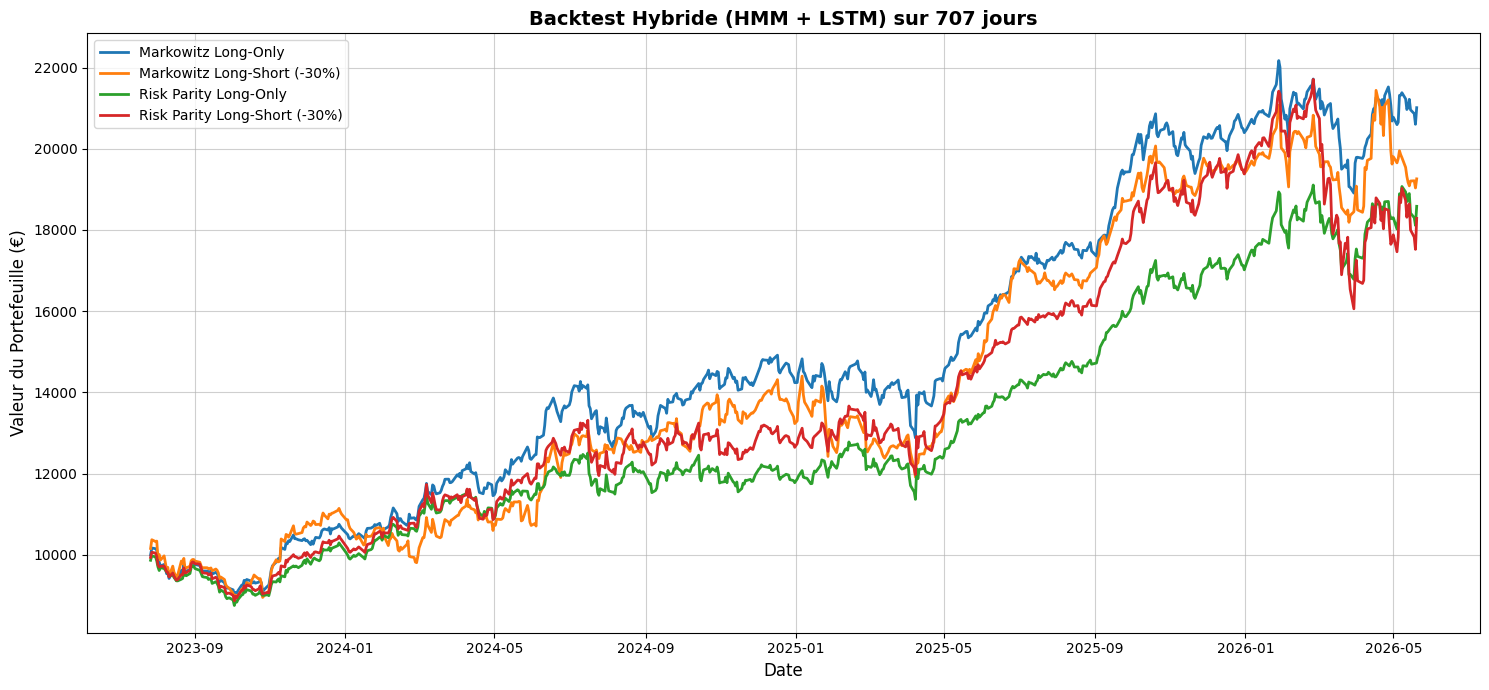

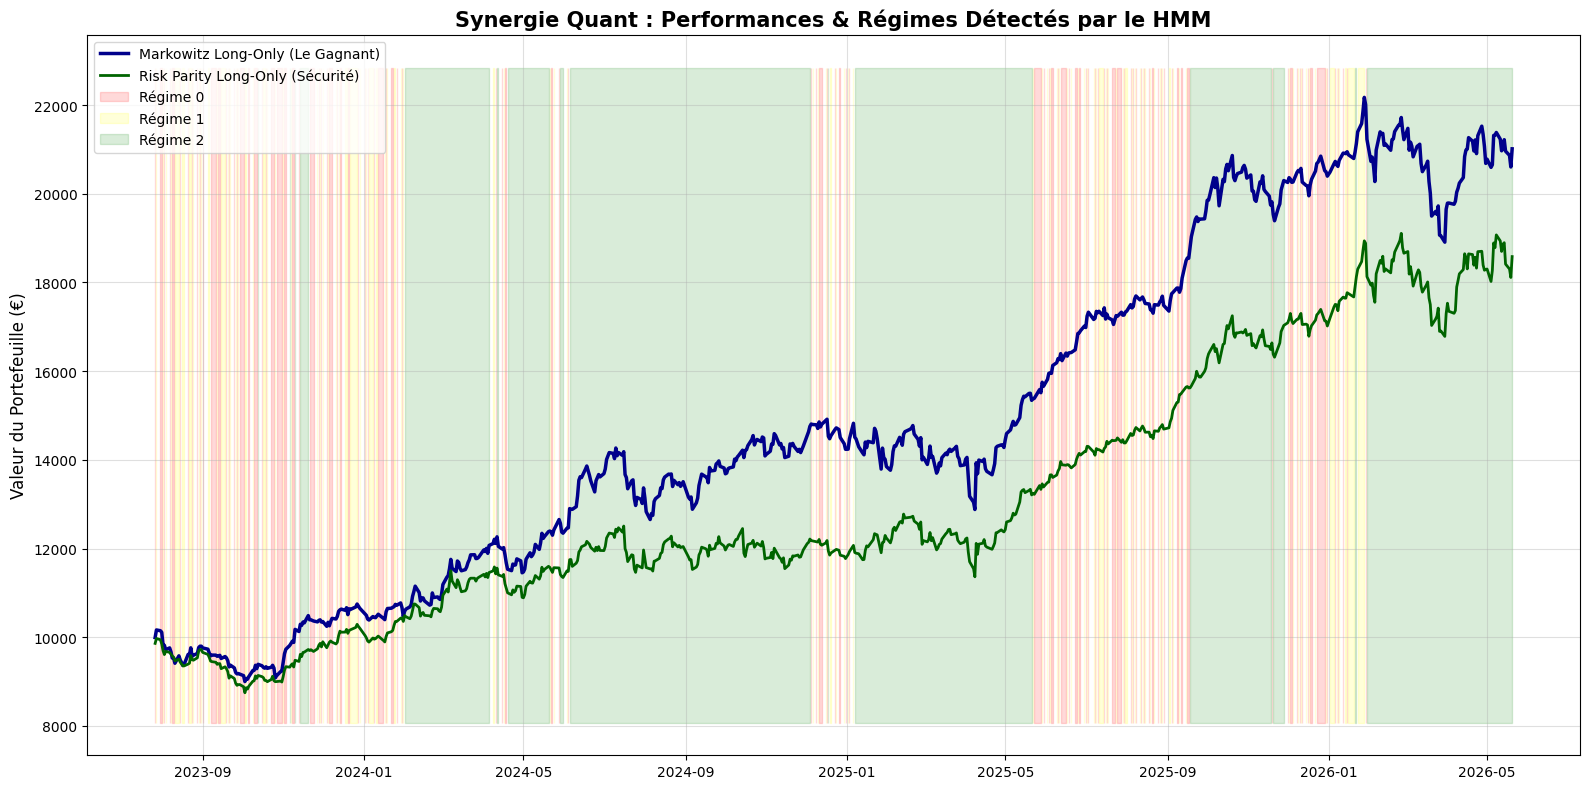

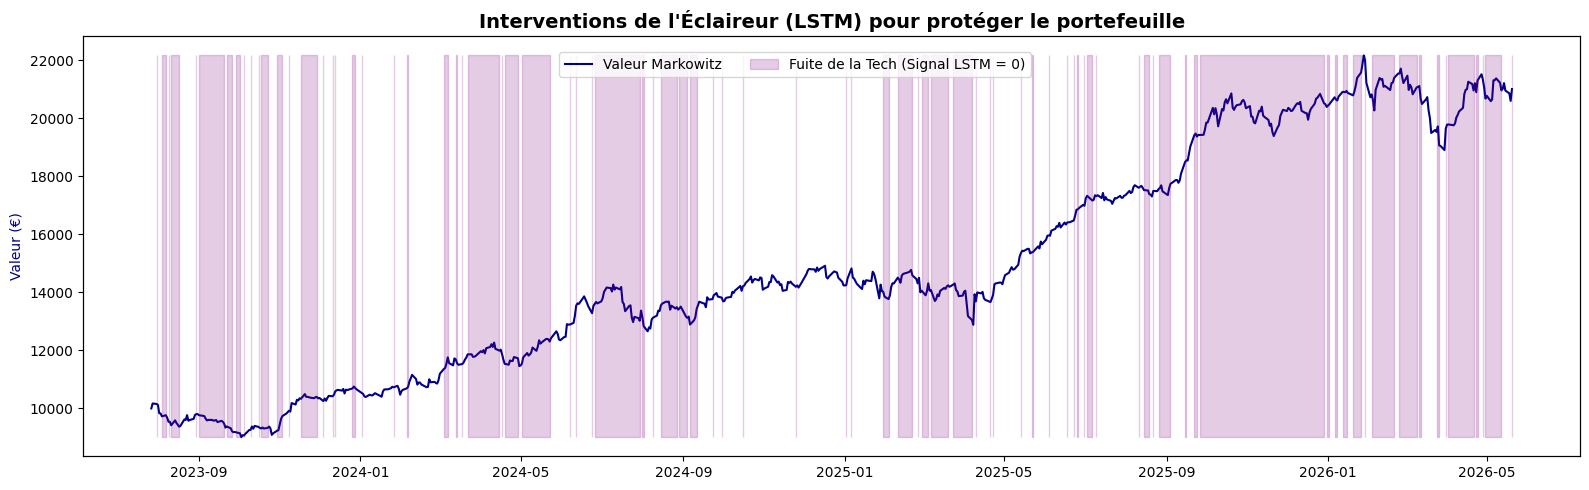

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convertir l'index en vrai format datetime si ce n'est pas déjà fait
results_df.index = pd.to_datetime(results_df.index)

# ==========================================
# GRAPHIQUE 1 : Évolution Simple des Portefeuilles
# ==========================================
plt.figure(figsize=(15, 7))
plt.plot(results_df.index, results_df['Markowitz_LongOnly'], label='Markowitz Long-Only', linewidth=2)
plt.plot(results_df.index, results_df['Markowitz_LongShort'], label='Markowitz Long-Short (-30%)', linewidth=2)
plt.plot(results_df.index, results_df['RiskParity_LongOnly'], label='Risk Parity Long-Only', linewidth=2)
plt.plot(results_df.index, results_df['RiskParity_LongShort'], label='Risk Parity Long-Short (-30%)', linewidth=2)

plt.title('Backtest Hybride (HMM + LSTM) sur 707 jours', fontsize=14, fontweight='bold')
plt.ylabel('Valeur du Portefeuille (€)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# GRAPHIQUE 2 : Performance avec Fonds Colorés (Régimes HMM)
# ==========================================
fig, ax = plt.subplots(figsize=(16, 8))

# On trace nos deux meilleurs modèles pour que ce soit lisible
ax.plot(results_df.index, results_df['Markowitz_LongOnly'], label='Markowitz Long-Only (Le Gagnant)', color='darkblue', linewidth=2.5)
ax.plot(results_df.index, results_df['RiskParity_LongOnly'], label='Risk Parity Long-Only (Sécurité)', color='darkgreen', linewidth=2)

# Couleurs des régimes (0 = Bear, 1 = Crab, 2 = Bull)
state_colors = {0: 'red', 1: 'yellow', 2: 'green'}

# Récupération des limites Y pour peindre le fond
ymin, ymax = ax.get_ylim()

# Colorier le fond selon le régime HMM
for regime in [0, 1, 2]:
    ax.fill_between(results_df.index, ymin, ymax,
                    where=(results_df['HMM_Regime'] == regime),
                    color=state_colors[regime], alpha=0.15, 
                    label=f'Régime {regime}')

# Éviter les doublons dans la légende pour les zones colorées
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.set_title("Synergie Quant : Performances & Régimes Détectés par le HMM", fontsize=15, fontweight='bold')
ax.set_ylabel("Valeur du Portefeuille (€)", fontsize=12)
ax.legend(by_label.values(), by_label.keys(), loc='upper left')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ==========================================
# GRAPHIQUE 3 : Analyse du Signal LSTM sur Markowitz
# ==========================================
fig, ax1 = plt.subplots(figsize=(16, 5))

# Tracer le PnL de Markowitz
ax1.plot(results_df.index, results_df['Markowitz_LongOnly'], color='darkblue', label='Valeur Markowitz')
ax1.set_ylabel('Valeur (€)', color='darkblue')

# Créer un deuxième axe Y pour afficher les moments où l'IA a "coupé" NVDA
ax2 = ax1.twinx()
ax2.fill_between(results_df.index, 0, 1, 
                 where=(results_df['Signal_Fabless'] == 0), 
                 color='purple', alpha=0.2, label='Fuite de la Tech (Signal LSTM = 0)')
ax2.set_yticks([]) # On cache les numéros de l'axe Y droit

plt.title("Interventions de l'Éclaireur (LSTM) pour protéger le portefeuille", fontsize=14, fontweight='bold')
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.9), ncol=2)
plt.tight_layout()
plt.show()

on essaye sans le signal pour comparer les 2

In [8]:
# On lance le backtest
assets_list = ['USO', 'ASML', 'TSM', 'NVDA', 'AAPL', 'MSFT', 'GLD', 'TLT']

results_df_without_lstm_from_lstm, weights_no_lstm = run_master_backtest(
    df_combined=data_combined,
    historical_means=historical_mean_returns,
    historical_covs=historical_cov_returns,
    assets=assets_list,
    k_days=21, # Rééquilibrage mensuel
    trust_lstm=0    #on ne fait pas confiance au lstm et donc on envoie le signal que l'on peut acheter du fabless (NVDA)
)

print(results_df_without_lstm_from_lstm.head())
print("\nValeur finale des portefeuilles :")
print(results_df_without_lstm_from_lstm[['Markowitz_LongOnly', 'Markowitz_LongShort', 'RiskParity_LongOnly', 'RiskParity_LongShort']].iloc[-1])

Début du Backtest sur 707 jours. Rééquilibrage tous les 21 jours.
            HMM_Regime  Signal_Fabless  Markowitz_LongOnly  \
Date                                                         
2023-07-27           0               1         9993.807851   
2023-07-28           1               1        10164.720094   
2023-07-31           0               0        10147.740979   
2023-08-01           0               1        10112.881766   
2023-08-02           1               1         9827.183240   

            Markowitz_LongShort  RiskParity_LongOnly  RiskParity_LongShort  
Date                                                                        
2023-07-27         10153.738390          9862.073219           9932.362698  
2023-07-28         10368.319695          9972.537903          10061.013075  
2023-07-31         10324.498832          9944.022446          10038.540676  
2023-08-01         10333.981690          9848.960134           9960.936107  
2023-08-02          9920.922867      

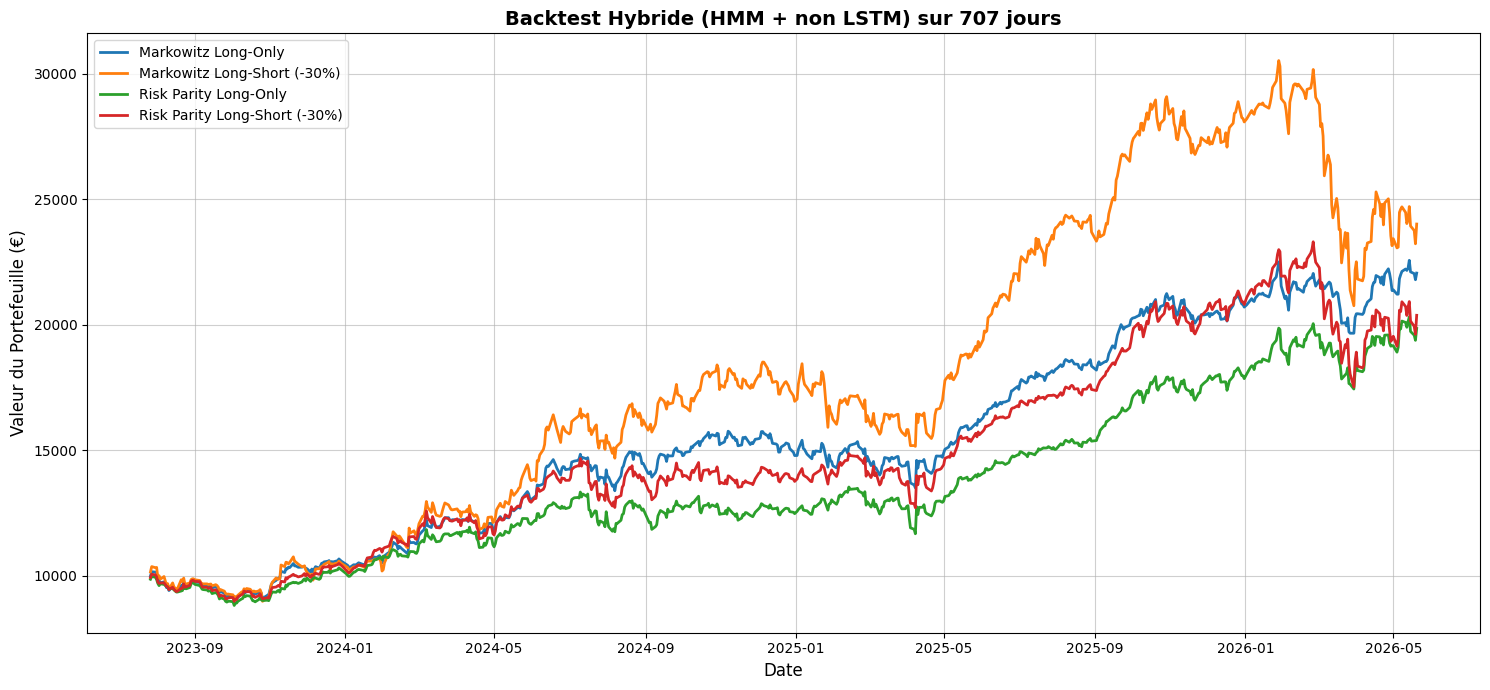

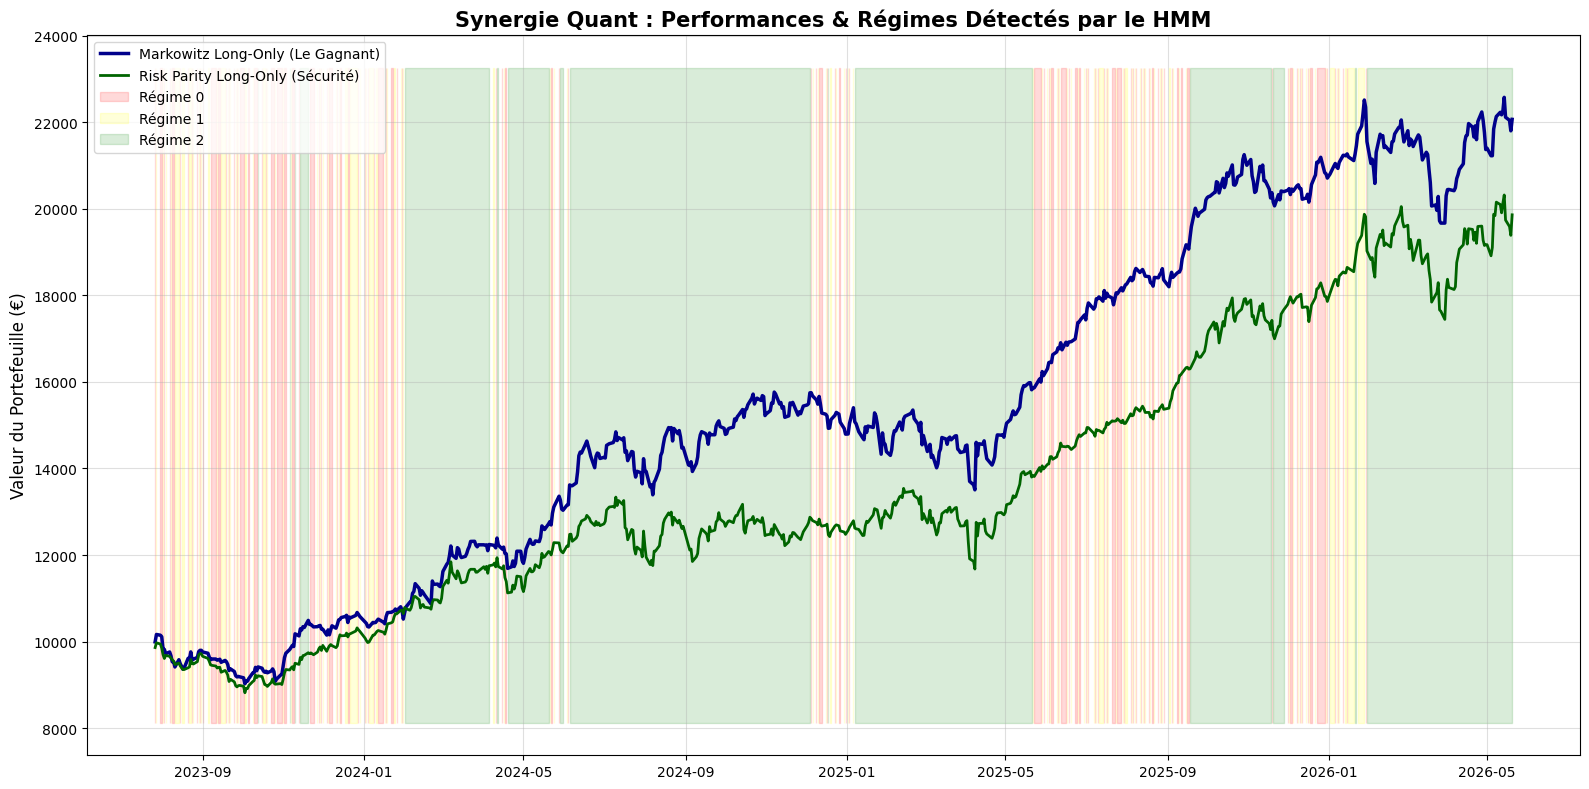

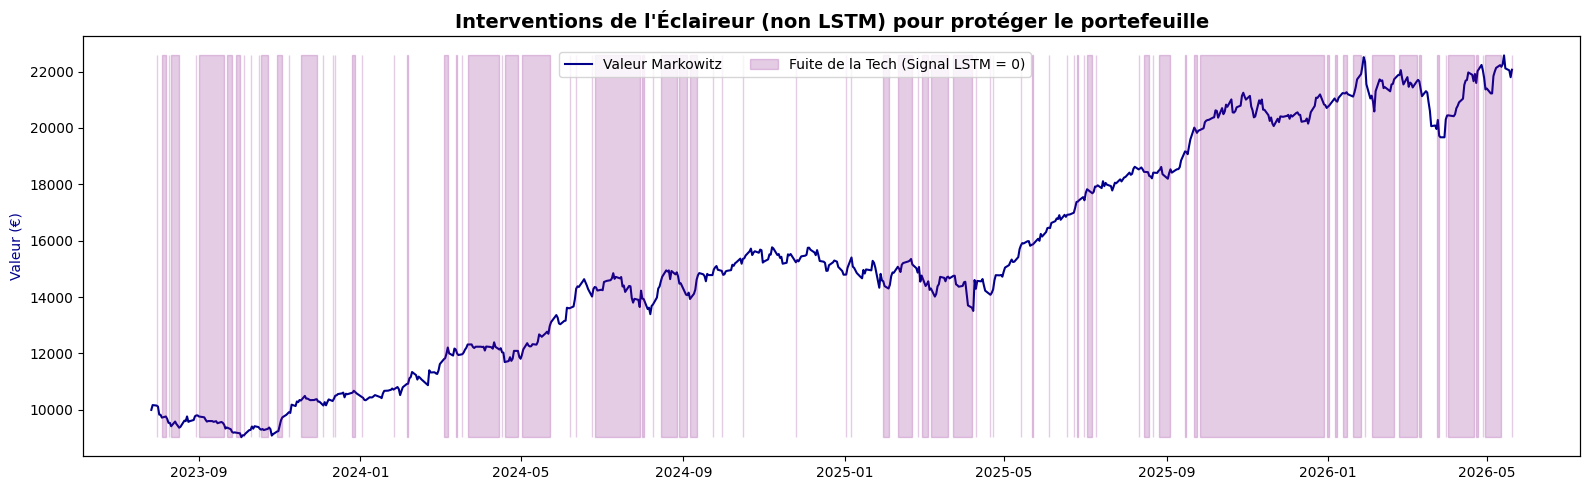

In [9]:
# Convertir l'index en vrai format datetime si ce n'est pas déjà fait
results_df_without_lstm_from_lstm.index = pd.to_datetime(results_df_without_lstm_from_lstm.index)

# ==========================================
# GRAPHIQUE 1 : Évolution Simple des Portefeuilles
# ==========================================
plt.figure(figsize=(15, 7))
plt.plot(results_df_without_lstm_from_lstm.index, results_df_without_lstm_from_lstm['Markowitz_LongOnly'], label='Markowitz Long-Only', linewidth=2)
plt.plot(results_df_without_lstm_from_lstm.index, results_df_without_lstm_from_lstm['Markowitz_LongShort'], label='Markowitz Long-Short (-30%)', linewidth=2)
plt.plot(results_df_without_lstm_from_lstm.index, results_df_without_lstm_from_lstm['RiskParity_LongOnly'], label='Risk Parity Long-Only', linewidth=2)
plt.plot(results_df_without_lstm_from_lstm.index, results_df_without_lstm_from_lstm['RiskParity_LongShort'], label='Risk Parity Long-Short (-30%)', linewidth=2)

plt.title('Backtest Hybride (HMM + non LSTM) sur 707 jours', fontsize=14, fontweight='bold')
plt.ylabel('Valeur du Portefeuille (€)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# GRAPHIQUE 2 : Performance avec Fonds Colorés (Régimes HMM)
# ==========================================
fig, ax = plt.subplots(figsize=(16, 8))

# On trace nos deux meilleurs modèles pour que ce soit lisible
ax.plot(results_df_without_lstm_from_lstm.index, results_df_without_lstm_from_lstm['Markowitz_LongOnly'], label='Markowitz Long-Only (Le Gagnant)', color='darkblue', linewidth=2.5)
ax.plot(results_df_without_lstm_from_lstm.index, results_df_without_lstm_from_lstm['RiskParity_LongOnly'], label='Risk Parity Long-Only (Sécurité)', color='darkgreen', linewidth=2)

# Couleurs des régimes (0 = Bear, 1 = Crab, 2 = Bull)
state_colors = {0: 'red', 1: 'yellow', 2: 'green'}

# Récupération des limites Y pour peindre le fond
ymin, ymax = ax.get_ylim()

# Colorier le fond selon le régime HMM
for regime in [0, 1, 2]:
    ax.fill_between(results_df_without_lstm_from_lstm.index, ymin, ymax,
                    where=(results_df_without_lstm_from_lstm['HMM_Regime'] == regime),
                    color=state_colors[regime], alpha=0.15, 
                    label=f'Régime {regime}')

# Éviter les doublons dans la légende pour les zones colorées
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.set_title("Synergie Quant : Performances & Régimes Détectés par le HMM", fontsize=15, fontweight='bold')
ax.set_ylabel("Valeur du Portefeuille (€)", fontsize=12)
ax.legend(by_label.values(), by_label.keys(), loc='upper left')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ==========================================
# GRAPHIQUE 3 : Analyse du Signal non LSTM sur Markowitz
# ==========================================
fig, ax1 = plt.subplots(figsize=(16, 5))

# Tracer le PnL de Markowitz
ax1.plot(results_df_without_lstm_from_lstm.index, results_df_without_lstm_from_lstm['Markowitz_LongOnly'], color='darkblue', label='Valeur Markowitz')
ax1.set_ylabel('Valeur (€)', color='darkblue')

# Créer un deuxième axe Y pour afficher les moments où l'IA a "coupé" NVDA
ax2 = ax1.twinx()
ax2.fill_between(results_df_without_lstm_from_lstm.index, 0, 1, 
                 where=(results_df_without_lstm_from_lstm['Signal_Fabless'] == 0), 
                 color='purple', alpha=0.2, label='Fuite de la Tech (Signal LSTM = 0)')
ax2.set_yticks([]) # On cache les numéros de l'axe Y droit

plt.title("Interventions de l'Éclaireur (non LSTM) pour protéger le portefeuille", fontsize=14, fontweight='bold')
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.9), ncol=2)
plt.tight_layout()
plt.show()

On remarque que sans le lstm durement acquis les modèles performe mieux notamment les risk parity sans lstm par rapport à leur version avec mais qu'en est il des risques encouru pour cela on regarde le max drawdown et le ratio de Sharpe

In [10]:
def print_risk_metrics(df_results, column_name):
    returns = df_results[column_name].pct_change().dropna()
    
    cum_ret = (df_results[column_name].iloc[-1] / df_results[column_name].iloc[0]) - 1
    
    # Sharpe Ratio (annualisé)
    mean_ann = returns.mean() * 252
    vol_ann = returns.std() * np.sqrt(252)
    sharpe = mean_ann / vol_ann if vol_ann != 0 else 0
    
    # Max Drawdown
    equity_curve = df_results[column_name] / df_results[column_name].iloc[0]
    running_max = equity_curve.cummax()
    drawdowns = (equity_curve - running_max) / running_max
    max_dd = drawdowns.min()
    
    print(f"--- {column_name} ---")
    print(f"Rendement Total : +{cum_ret*100:.2f}%")
    print(f"Sharpe Ratio    : {sharpe:.2f}")
    print(f"Max Drawdown    : {max_dd*100:.2f}%\n")

print("=== AVEC LSTM (Normalement plus prudent) ===")
print_risk_metrics(results_df, 'Markowitz_LongOnly')

print("=== SANS LSTM (Nomalement plus agressif) ===")
print_risk_metrics(results_df_without_lstm_from_lstm, 'Markowitz_LongOnly')

=== AVEC LSTM (Normalement plus prudent) ===
--- Markowitz_LongOnly ---
Rendement Total : +110.26%
Sharpe Ratio    : 1.55
Max Drawdown    : -14.73%

=== SANS LSTM (Nomalement plus agressif) ===
--- Markowitz_LongOnly ---
Rendement Total : +120.79%
Sharpe Ratio    : 1.63
Max Drawdown    : -14.33%



On voit que le modèle sans LSTM fonctionne mieux partout :
- rendement total
- Sharpe ratio (ratio rendement/risque)
- max drawdown (pire chute du portefeuille)

On sauvegarde pour l'api

In [11]:
api_dir = '../data/api_data'
os.makedirs(api_dir, exist_ok=True)

# 1. Les Inputs de base
data_combined.to_csv(f'{api_dir}/inputs_oracles.csv', index=False)

# 2. Les Courbes d'équité (Les portefeuilles en €)
results_df.reset_index().rename(columns={'index': 'Date'}).to_csv(f'{api_dir}/equity_with_lstm.csv', index=False)
results_df_without_lstm_from_lstm.reset_index().rename(columns={'index': 'Date'}).to_csv(f'{api_dir}/equity_no_lstm.csv', index=False)

# 3. Les Poids des 8 portefeuilles (4 avec, 4 sans)
for model_name, df_weights in weights_with_lstm.items():
    df_weights.reset_index().rename(columns={'index': 'Date'}).to_csv(f'{api_dir}/weights_with_lstm_{model_name}.csv', index=False)

for model_name, df_weights in weights_no_lstm.items():
    df_weights.reset_index().rename(columns={'index': 'Date'}).to_csv(f'{api_dir}/weights_no_lstm_{model_name}.csv', index=False)

# Conclusion Générale :

L'étude comparative finale entre un modèle [HMM + Markowitz] et un modèle [HMM + LSTM + Markowitz] a révélé une vérité fondamentale de l'ingénierie financière : la complexité n'est pas toujours synonyme de performance.

L'ajout du réseau de neurones LSTM, malgré des métriques théoriques correctes en classification, a détérioré la performance globale du portefeuille (-10% de rendement, dégradation du Sharpe Ratio). Le LSTM a souffert de l'effet 'Whipsaw' (retard de signal générant des ventes à contretemps lors des rebonds en V).

Cependant, ce test d'ablation prouve l'extrême robustesse de notre premier modèle de Machine Learning : le Hidden Markov Model (HMM). À lui seul, couplé à l'optimiseur de Markowitz, le HMM a réussi à doubler le capital (+120%) tout en maintenant un Max Drawdown inférieur à 15% sur près de 3 ans de marché. Le HMM s'avère être un gestionnaire de régime (macro) amplement suffisant, rendant l'overlay prédictif du LSTM (micro) non seulement redondant, mais contre-productif à certain moment.

## Conclusion post-création API avec plusieurs tests (notamment testé toutes les stratégies entre 12 mai 2025 et 12 mai 2026)

L'interrogation de notre API sur une période de test d'un an (2025-2026) permet de tirer des conclusions définitives sur l'hybridation entre l'Optimisation Classique (Markowitz / Risk Parity) et le Deep Learning (LSTM).

L'IA n'est pas une baguette magique de rendement, c'est un gestionnaire de risque contextuel.

Les données de l'API démontrent que dans un marché fortement haussier, les stratégies directionnelles simples (Long-Only sans IA) surperforment en rendement absolu. Le LSTM, entraîné avec des Class Weights pour être très sensible aux baisses, agit comme un frein qui génère un coût d'opportunité lors des forts rallyes haussiers.

Cependant, la véritable valeur ajoutée du modèle LSTM se révèle dans les configurations à haut risque, notamment la stratégie Markowitz Long/Short. Sans filet de sécurité, autoriser la vente à découvert dans un marché volatil a conduit l'algorithme mathématique classique à un Drawdown sévère de -32%.

En activant le "Bouclier LSTM", l'IA a bloqué les positions vendeuses à contre-tendance sur le secteur technologique, réduisant le Drawdown à seulement -17.28%.

Bilan du Projet ChipChainReaction :

Nous avons réussi à prouver qu'une modélisation de la Supply Chain via Machine Learning ne sert pas à prédire le prix de demain, mais à "désarmer" un portefeuille mathématique agressif juste avant qu'il ne commette une erreur fatale. Le couple [HMM (Macro) + LSTM (Micro) + Markowitz (Allocation)] forme un système institutionnel complet, où chaque brique pallie les faiblesses des autres.